## **Análisis Exploratorio - Clustering**

INICIANDO PIPELINE DE CLUSTERING - Colab
 Carpeta de salidas: /content/outputs_clustering_housing
=== PASO 1: CARGA DE DATOS ===
✅ Dataset cargado: 1,460 filas × 81 columnas

→ Outliers tratados con winsor (limit=0.01) en 36 variables

=== PASO 2: SELECCIÓN DE VARIABLES ===

=== PASO 3: PREPROCESAMIENTO COMPLETO ===
→ Outliers tratados con winsor (limit=0.01) en 25 variables

=== PASO 4: EVALUACIÓN (ELBOW) ===


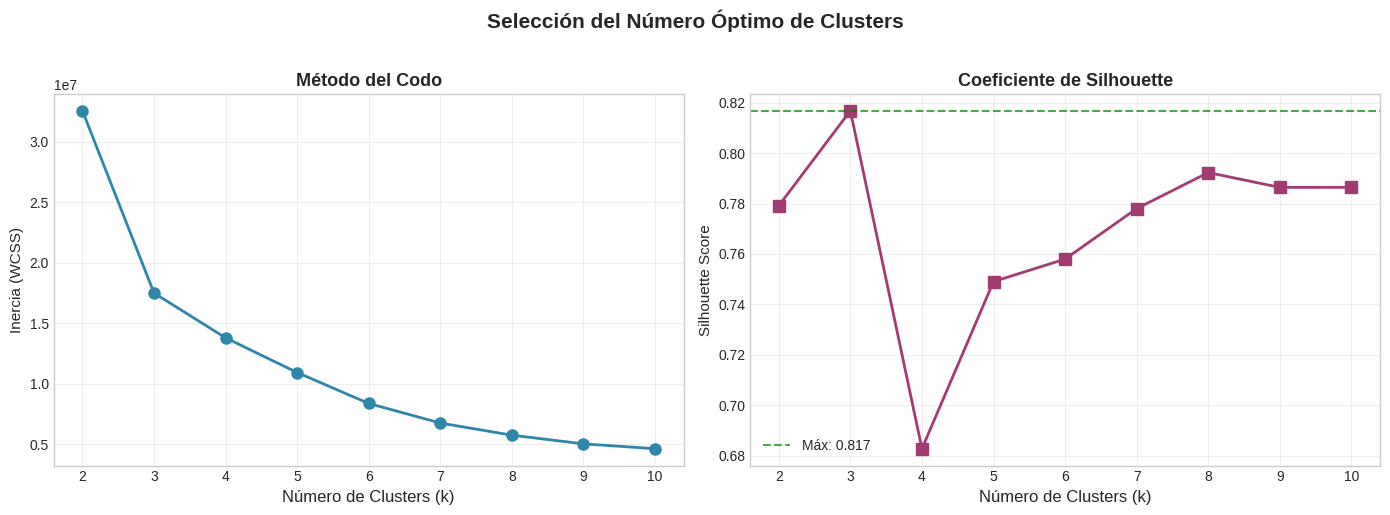

    Gráfico guardado: elbow_silhouette.png
   💡 Sugerencia automática: k=3

=== PASO 5: ENTRENAMIENTO K-MEANS (k=4) ===
✅ Modelo entrenado. Silhouette: 0.6827

=== PASO 6 & 7: PERFILES Y VISUALIZACIONES ===

📋 PERFILES DE LOS CLUSTERS - INTERPRETACIÓN DE SEGMENTOS DE VIVIENDAS

         Cantidad  Precio_Venta_Medio  Area_Habitable_Media_m2  Calidad_General_Media  Antiguedad_Media_anos
Cluster                                                                                                     
0            1167            187831.1                   1536.8                    6.2                   49.1
1              91            171884.9                   1448.1                    5.7                   61.6
3              51            154561.8                   1415.9                    5.5                   66.8
2             151            141866.8                   1424.9                    5.5                   90.4

 Perfiles guardados en: cluster_profiles.csv


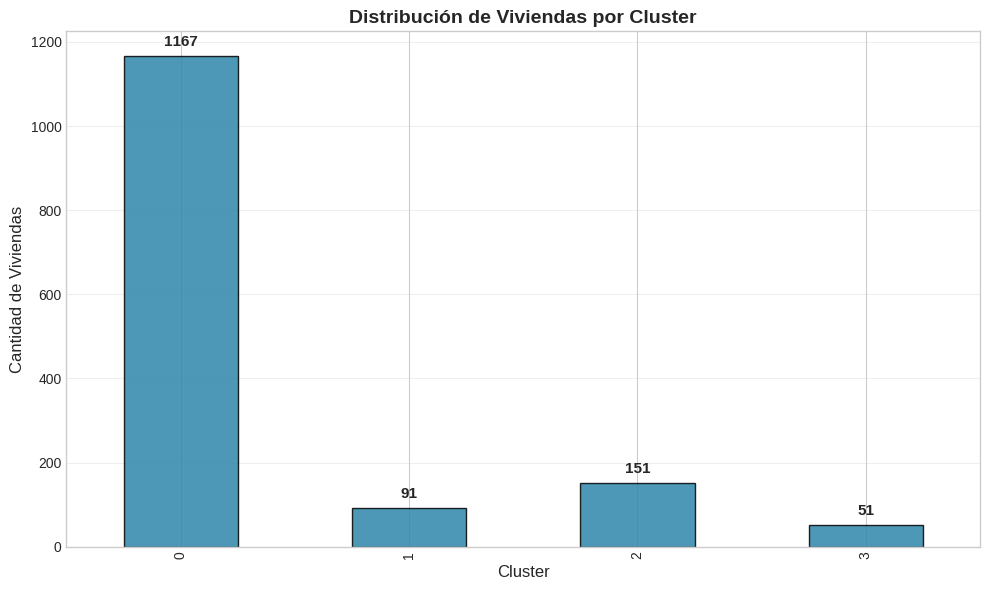

    Distribución guardada: cluster_distribution.png


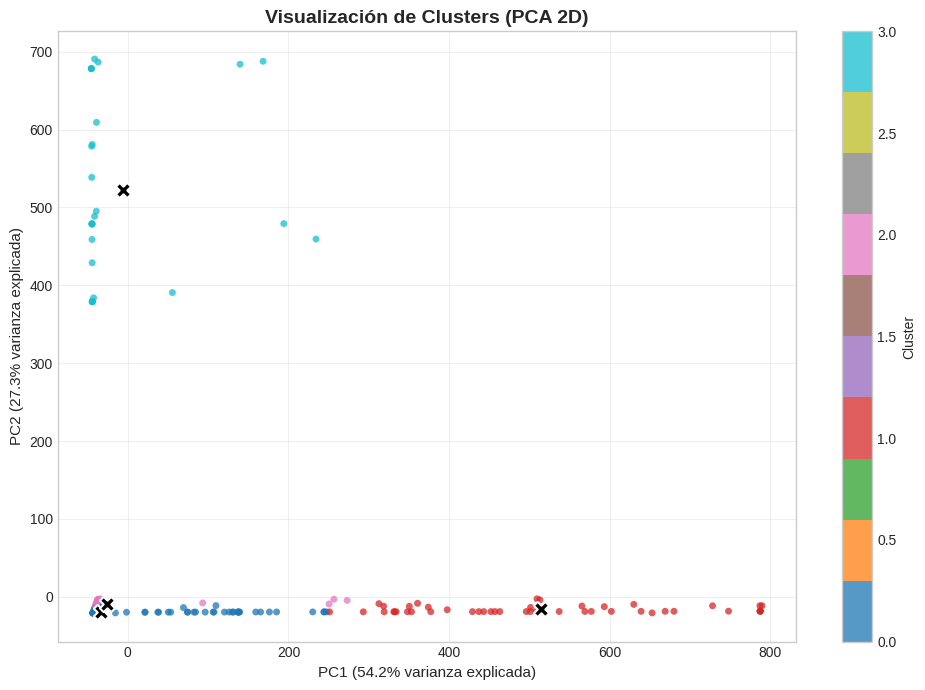

    PCA 2D guardado: clusters_pca_2d.png
    Generando 8 boxplots por cluster...
    8 boxplots guardados en outputs_clustering_housing

=== PASO 8: GUARDADO DE RESULTADOS ===
✅ Modelos y CSV guardados en la carpeta: outputs_clustering_housing


In [ ]:
# =============================================================================
# LIBRERÍAS Y CONFIGURACIÓN INICIAL PARA COLAB
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import joblib
import os

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

import warnings
warnings.filterwarnings('ignore')

# Configuración global del proyecto
CONFIG = {
    "DATA_PATH": Path("train.csv"),
    "OUTPUT_DIR": Path("outputs_clustering_housing"),
    "PK_COL": "Id",
    "TARGET_COL": "SalePrice",
    "RANDOM_STATE": 42,
    "WINSOR_LIMIT": 0.01,
    "CORR_THRESHOLD": 0.55,
    "ELBOW_MAX_K": 10,
    "N_CLUSTERS": 4, # Puedes cambiar esto tras ver el gráfico de codo
    "MAX_BOXPLOTS": 8
}

def create_output_dir():
    """Crea carpeta de salidas si no existe"""
    CONFIG["OUTPUT_DIR"].mkdir(parents=True, exist_ok=True)
    print(f" Carpeta de salidas: {CONFIG['OUTPUT_DIR'].resolve()}")

# =============================================================================
# FUNCIONES DE PREPROCESAMIENTO (MEJORADAS)
# =============================================================================
def custom_impute(df, special_cols=None):
    """
    Imputación robusta con mediana.
    Para train.csv: LotFrontage, MasVnrArea, GarageYrBlt suelen tener nulos.
    """
    df_imputed = df.copy()
    numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if df_imputed[col].isnull().sum() > 0:
            median_val = df_imputed[col].median()
            df_imputed[col] = df_imputed[col].fillna(median_val)

    if special_cols:
        for col in special_cols:
            if col in df_imputed.columns:
                missing_pct = df[col].isnull().mean() * 100
                print(f"   → {col}: {missing_pct:.2f}% missing → imputado con mediana")

    return df_imputed

def handle_outliers(df, method='winsor', limit=0.01):
    """Winsorización o clipping IQR para proteger a K-Means."""
    df_clean = df.copy()
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if method == 'winsor':
            lower = df_clean[col].quantile(limit)
            upper = df_clean[col].quantile(1 - limit)
            df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
        elif method == 'clip':
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 3 * IQR
            upper = Q3 + 3 * IQR
            df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    print(f"→ Outliers tratados con {method} (limit={limit}) en {len(numeric_cols)} variables")
    return df_clean

def remove_correlated_features(df, threshold=0.55):
    """Elimina variables altamente correlacionadas."""
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    reduced_df = df.drop(columns=to_drop, errors='ignore')
    return reduced_df, to_drop

def get_winsor_bounds(df, limit=0.01):
    """Calcula límites de winsorización por variable."""
    bounds = {}
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        bounds[col] = {
            'lower': df[col].quantile(limit),
            'upper': df[col].quantile(1 - limit)
        }
    return bounds

# =============================================================================
# VISUALIZACIONES Y EDA (Adaptado para Colab)
# =============================================================================
def plot_correlation_heatmap(df, title="Mapa de Correlaciones"):
    plt.figure(figsize=(max(12, len(df.columns)*0.6), max(10, len(df.columns)*0.5)))
    sns.heatmap(df.corr(), cmap='coolwarm', annot=False, vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    path = CONFIG["OUTPUT_DIR"] / "correlation_heatmap.png"
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show() # Añadido para Colab
    print(f"  Heatmap guardado: {path.name}")

def plot_elbow_and_silhouette(X_scaled, max_k=10):
    inertias = []
    silhouettes = []
    K_range = range(2, max_k + 1)

    for k in K_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=CONFIG["RANDOM_STATE"])
        km.fit(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, km.labels_))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(K_range, inertias, 'o-', color='#2E86AB', linewidth=2, markersize=8)
    ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
    ax1.set_ylabel('Inercia (WCSS)', fontsize=11)
    ax1.set_title('Método del Codo', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.plot(K_range, silhouettes, 's-', color='#A23B72', linewidth=2, markersize=8)
    ax2.set_xlabel('Número de Clusters (k)', fontsize=12)
    ax2.set_ylabel('Silhouette Score', fontsize=11)
    ax2.set_title('Coeficiente de Silhouette', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=max(silhouettes), color='green', linestyle='--', alpha=0.7, label=f'Máx: {max(silhouettes):.3f}')
    ax2.legend()

    plt.suptitle('Selección del Número Óptimo de Clusters', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    path = CONFIG["OUTPUT_DIR"] / "elbow_silhouette.png"
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show() # Añadido para Colab
    print(f"    Gráfico guardado: {path.name}")

    best_k_sil = K_range[np.argmax(silhouettes)]
    print(f" Sugerencia automática: k={best_k_sil}")

def plot_cluster_distribution(labels):
    cluster_dist = pd.Series(labels).value_counts().sort_index()

    plt.figure(figsize=(10, 6))
    ax = cluster_dist.plot(kind='bar', color='#2E86AB', edgecolor='black', alpha=0.85)
    plt.title('Distribución de Viviendas por Cluster', fontsize=14, fontweight='bold')
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Cantidad de Viviendas', fontsize=12)

    for i, v in enumerate(cluster_dist):
        ax.text(i, v + max(cluster_dist)*0.015, str(v), ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    path = CONFIG["OUTPUT_DIR"] / "cluster_distribution.png"
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"    Distribución guardada: {path.name}")

def plot_pca_2d(X_scaled, labels, title="Visualización de Clusters (PCA 2D)"):
    n_sample = min(800, len(labels))
    sample_idx = np.random.choice(len(labels), n_sample, replace=False)
    X_sample = X_scaled[sample_idx]
    labels_sample = labels[sample_idx]

    pca = PCA(n_components=2, random_state=CONFIG["RANDOM_STATE"])
    X_pca = pca.fit_transform(X_sample)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_sample, cmap='tab10',
                          alpha=0.75, s=25, edgecolor='none')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza explicada)', fontsize=11)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza explicada)', fontsize=11)
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True, alpha=0.3)

    for i in np.unique(labels_sample):
        mask = labels_sample == i
        if mask.sum() > 0:
            cx, cy = X_pca[mask].mean(axis=0)
            plt.scatter(cx, cy, c='black', s=120, marker='X', edgecolor='white', linewidths=1.5, zorder=10)

    plt.tight_layout()
    path = CONFIG["OUTPUT_DIR"] / "clusters_pca_2d.png"
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"    PCA 2D guardado: {path.name}")

def plot_boxplots_per_cluster(X_scaled, labels, features, max_plots=8):
    df_viz = pd.DataFrame(X_scaled, columns=features)
    df_viz['Cluster'] = labels
    n_plots = min(max_plots, len(features))
    selected_feats = features[:n_plots]

    print(f"    Generando {n_plots} boxplots por cluster...")
    for feat in selected_feats:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x='Cluster', y=feat, data=df_viz, palette='viridis', showfliers=False)
        sns.stripplot(x='Cluster', y=feat, data=df_viz, color='black', alpha=0.15, size=2, jitter=0.2)
        plt.title(f'Distribución de "{feat}" por Cluster', fontsize=11, fontweight='bold')
        plt.tight_layout()
        path = CONFIG["OUTPUT_DIR"] / f"boxplot_{feat}.png"
        plt.savefig(path, dpi=300, bbox_inches='tight')
        plt.close() # Aquí cerramos para no saturar la salida en Colab
    print(f"    {n_plots} boxplots guardados en {CONFIG['OUTPUT_DIR']}")

def generate_cluster_profiles(df, features, labels):
    print("\n" + "="*70)
    print("📋 PERFILES DE LOS CLUSTERS - INTERPRETACIÓN DE SEGMENTOS DE VIVIENDAS")
    print("="*70)

    df = df.copy()
    df['Cluster'] = labels

    profile_vars = {
        'Cantidad': ('Cluster', 'count'),
        'Precio_Venta_Medio': (CONFIG["TARGET_COL"], 'mean'),
        'Area_Habitable_Media_m2': ('GrLivArea', 'mean'),
        'Calidad_General_Media': ('OverallQual', 'mean'),
        'Antiguedad_Media_anos': ('YearBuilt', lambda x: datetime.now().year - x.mean())
    }

    agg_dict = {name: (col, agg) for name, (col, agg) in profile_vars.items() if col in df.columns}

    profile = df.groupby('Cluster').agg(**agg_dict).round(1)
    if 'Precio_Venta_Medio' in profile.columns:
        profile = profile.sort_values('Precio_Venta_Medio', ascending=False)

    print("\n" + profile.to_string())
    profile_path = CONFIG["OUTPUT_DIR"] / "cluster_profiles.csv"
    profile.to_csv(profile_path)
    print(f"\n Perfiles guardados en: {profile_path.name}")
    return profile

# =============================================================================
# FUNCIÓN PRINCIPAL
# =============================================================================
def main():

    print("INICIANDO PIPELINE DE CLUSTERING - Colab")


    if not CONFIG["DATA_PATH"].exists():
        print(f" ERROR: No se encuentra '{CONFIG['DATA_PATH']}'.")
        print("Sube el archivo 'train.csv' al panel izquierdo de Colab y vuelve a ejecutar.")
        return

    create_output_dir()

    print("=== PASO 1: CARGA DE DATOS ===")
    df = pd.read_csv(CONFIG["DATA_PATH"])
    print(f"Dataset cargado: {len(df):,} filas × {len(df.columns)} columnas\n")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_cols = [CONFIG["PK_COL"], CONFIG["TARGET_COL"]]
    feature_cols = [c for c in numeric_cols if c not in exclude_cols]

    df_clean = custom_impute(df[feature_cols])
    df_clean = handle_outliers(df_clean, method='winsor', limit=CONFIG["WINSOR_LIMIT"])

    print("\n=== PASO 2: SELECCIÓN DE VARIABLES ===")
    df_reduced, dropped = remove_correlated_features(df_clean, threshold=CONFIG["CORR_THRESHOLD"])
    selected_features = df_reduced.columns.tolist()

    print("\n=== PASO 3: PREPROCESAMIENTO COMPLETO ===")
    X = df[selected_features].copy()
    X = custom_impute(X)
    X = handle_outliers(X, method='winsor', limit=CONFIG["WINSOR_LIMIT"])

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    print("\n=== PASO 4: EVALUACIÓN (ELBOW) ===")
    plot_elbow_and_silhouette(X_scaled, max_k=CONFIG["ELBOW_MAX_K"])

    print(f"\n=== PASO 5: ENTRENAMIENTO K-MEANS (k={CONFIG['N_CLUSTERS']}) ===")
    kmeans = KMeans(n_clusters=CONFIG["N_CLUSTERS"], n_init=10, random_state=CONFIG["RANDOM_STATE"])
    labels = kmeans.fit_predict(X_scaled)
    print(f" Modelo entrenado. Silhouette: {silhouette_score(X_scaled, labels):.4f}\n")

    print("=== PASO 6 & 7: PERFILES Y VISUALIZACIONES ===")
    profile = generate_cluster_profiles(df, selected_features, labels)
    plot_cluster_distribution(labels)
    plot_pca_2d(X_scaled, labels)
    plot_boxplots_per_cluster(X_scaled, labels, selected_features, max_plots=CONFIG["MAX_BOXPLOTS"])

    print("\n=== PASO 8: GUARDADO DE RESULTADOS ===")
    output_df = df.copy()
    output_df['Cluster'] = labels
    output_df.to_csv(CONFIG["OUTPUT_DIR"] / "train_clustered.csv", index=False)

    joblib.dump(kmeans, CONFIG["OUTPUT_DIR"] / "kmeans_model.pkl")
    joblib.dump(scaler, CONFIG["OUTPUT_DIR"] / "scaler.pkl")
    print(" Modelos y CSV guardados en la carpeta:", CONFIG["OUTPUT_DIR"].name)

# =============================================================================
# EJECUCIÓN
# =============================================================================
if __name__ == "__main__":
    main()